Deep Learning Models: A collection of various deep learning architectures, models, & their implementations (`PyTorch` or `TensorFlow`) in Jupyter Notebooks.
* Author: _Chizoba Obasi_
* Github Repo: https://github.com/chizkidd/deep-learning-models

In [1]:
!pip install watermark

In [2]:
%load_ext watermark
# %reload_ext watermark
%watermark -a 'Chizoba Obasi' -v -p torch

Author: Chizoba Obasi

Python implementation: CPython
Python version       : 3.11.13
IPython version      : 7.34.0

torch: 2.6.0+cu124



# VGG-16 Classifier on CIFAR-10

**Network Architecture:**

![](https://media.licdn.com/dms/image/v2/D5612AQH9utb1Vs1YOw/article-cover_image-shrink_600_2000/article-cover_image-shrink_600_2000/0/1712342077540?e=2147483647&v=beta&t=rVwtI1iPmVIu_vpgTK9Eo6CprbdKdw7e4NZVd30t_8M)

[Image Source](https://www.linkedin.com/pulse/demystifying-vgg16-powerful-tool-your-deep-learning-arsenal-m-kxotc)

**ConveNet Configuration:**

Network has 5 convolutional stages:
1. `conv`->`conv`
2. `conv`->`conv`
3. `conv`->`conv`->`conv`->[`conv`]
4. `conv`->`conv`->`conv`->[`conv`]
5. `conv`->`conv`->`conv`->[`conv`]
6. `FC`->`FC`->`FC`

> - VGG-16 has 16 layers if you count all the `conv` and `FC` layers except the bracketed conv [`conv`].
> - VGG-19 has the extra bracketed conv [`conv`] in **stages 3, 4 and 5** .

**Design Rules:**
1. All `conv` are $3\times3$ with`stride` of $1$ and `padding` of $1$
2. All `maxpool` are $2\times2$ with `stride` of $2$
3. After `maxpool`, **double # of channels**

**Notes:**
1. Two $3\times3$ `conv` has same receptive field as a single $5\times5$ `conv`, but has fewer parameters and takes less computation!

|Options|1|2|
|-|-|-|
|Setup| CONV($5\times5$, $C \rightarrow C$) | **2x** CONV($3\times3$, $C \rightarrow C$) |
|Params| $25C^2$ | $2 \times 9C^2 = 18C^2$ |
|FLOPs| $25C^2HW$ | $18C^2HW$ |

2. `conv` layers at each spatial resolution take the same amount of computation!

|Config|1|2|
|-|-|-|
|Input| $C \times 2H \times 2W$| $2C \times H \times W$ |
|Layer| CONV($3\times3$, $C \rightarrow C$) | CONV($3\times3$, $2C \rightarrow 2C$) |
|Memory| $4HWC$ | $2HWC$ |
|Params| $9C^2$ | $2 \times 9C^2 = 36C^2$ |
|FLOPs| $36C^2HW$ | $36C^2HW$ |



**REFERENCES:**
1. Simonyan, Karen, and Andrew Zisserman. ["Very Deep Convolutional Networks for Large-Scale Image Recognition."](https://arxiv.org/pdf/1409.1556) International Conference on Learning Representations (ICLR), 2015. arXiv:1409.1556.
2. Johnson, J. (2022, February 2). _Lecture 8: CNN Architectures_ [PowerPoint Slides]. University of Michigan EECS 498/598: Deep Learning for Computer Vision. pp 56-65. https://web.eecs.umich.edu/~justincj/slides/eecs498/WI2022/598_WI2022_lecture08.pdf

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from sklearn.model_selection import train_test_split

import matplotlib.image as mpimg
import matplotlib.pyplot as plt
%matplotlib inline

import pandas as pd
import numpy as np
import math
import time
import os
import random

if torch.cuda.is_available():
    torch.backends.cudnn.deterministic = True

In [4]:
!pip install torchinfo

In [5]:
from torchinfo import summary

In [6]:
def set_all_seeds(seed):
    os.environ["PL_GLOBAL_SEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

def set_deterministic():
    if torch.cuda.is_available():
        torch.backends.cudnn.benchmark = False
        torch.backends.cudnn.deterministic = True
    torch.set_deterministic(True)

In [7]:
# Check if GPU is available and set the device
if torch.cuda.is_available():
    num_gpus = torch.cuda.device_count()
    print("Num GPUs Available: ", num_gpus)
    for i in range(num_gpus):
        gpu_name = torch.cuda.get_device_name(i)
        print(f"GPU {i}: {gpu_name}")
else:
    print("No GPU available.")


Num GPUs Available:  2
GPU 0: Tesla T4
GPU 1: Tesla T4


---
# 0. Model Hyperparameters
---

In [8]:
##########################
### SETTINGS
##########################

# Hyperparameters
RANDOM_SEED = 123
BATCH_SIZE = 128 #256
LEARNING_RATE = 0.001
NUM_EPOCHS = 20
INPUT_SIZE = 32 # CIFAR-10 is 32x32
NUM_CLASSES = 10

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


---
# 1. Data Preparation & Loading

---

In [9]:
# Mean and Std Dev for CIFAR-10 (3 channels)
CIFAR_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR_STD = (0.2471, 0.2435, 0.2616)

# Data Augmentation (Crucial for VGG-16 on CIFAR-10)
train_transforms = transforms.Compose([
    transforms.RandomCrop(32, padding=4),   # Crop after padding
    transforms.RandomHorizontalFlip(),      # Flip
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD) # Mean Subtraction
])

# Test/Validation Transforms (No Augmentation)
test_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD)
])

# Load Datasets
train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=train_transforms)
test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=test_transforms)

# Split training set into training and validation sets
train_size = int(0.9 * len(train_dataset))
val_size = len(train_dataset) - train_size
train_subset, val_subset = torch.utils.data.random_split(train_dataset, [train_size, val_size])

# Create DataLoaders
train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

100%|██████████| 170M/170M [00:04<00:00, 35.4MB/s] 


---
# 2. Model Creation

---

In [10]:
# VGG-16 Architecture (List of output channels for each layer)
# M denotes a MaxPool2d layer
VGG16_arch = [64, 64, 'M', 128, 128, 'M', 256, 256, 256, 'M', 512, 512, 512, 'M', 512, 512, 512, 'M']

class VGG(nn.Module):
    def __init__(self, features, num_classes=10):
        super(VGG, self).__init__()
        
        # Convolutional Block
        self.features = features

        # 2x2 MaxPool (stride=2): 32x32 -> 16x16 -> 8x8 -> 4x4 -> 2x2 -> 1x1 
        # The final feature map size is 1x1 with 512 channels.
        
        # Classifier Block
        self.classifier = nn.Sequential(
            nn.Linear(512 * 1 * 1, 4096),  # Final feature size is 512x1x1
            nn.ReLU(True),
            nn.Dropout(),
            nn.Linear(4096, 4096),
            nn.ReLU(True),
            nn.Dropout(),
            nn.Linear(4096, num_classes)
        )
        
        # Initialize weights (Crucial for VGG to train well)
        self._initialize_weights()

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1) 
        logits = self.classifier(x)
        return logits
    
    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')  # Kaiming init standard for ReLU
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01)
                nn.init.constant_(m.bias, 0)

# Helper function to create the feature extractor based on VGG16_arch
def make_layers(cfg, batch_norm=False):
    layers = []
    in_channels = 3 # Start with 3 color channels
    for v in cfg:
        if v == 'M':
            layers += [nn.MaxPool2d(kernel_size=2, stride=2)]
        else:
            conv2d = nn.Conv2d(in_channels, v, kernel_size=3, padding=1)
            if batch_norm:
                layers += [conv2d, nn.BatchNorm2d(v), nn.ReLU(inplace=True)]
            else:
                layers += [conv2d, nn.ReLU(inplace=True)]
            in_channels = v
    return nn.Sequential(*layers)

# Instantiate the Model 
set_all_seeds(RANDOM_SEED)
vgg16_features = make_layers(VGG16_arch, batch_norm=True) # Use Batch Norm for better convergence
model = VGG(vgg16_features, num_classes=NUM_CLASSES).to(device)


# Print VGG16 architecture
print(vgg16_features)


# Print Summary
print("--- VGG-16 Model Summary ---")
summary(model, 
        input_size=(BATCH_SIZE, 3, INPUT_SIZE, INPUT_SIZE), 
        col_names=["input_size", "output_size", "num_params", "kernel_size", "mult_adds"]
       )

Sequential(
  (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (5): ReLU(inplace=True)
  (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (7): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (8): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (9): ReLU(inplace=True)
  (10): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (11): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (12): ReLU(inplace=True)
  (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (14): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Kernel Shape              Mult-Adds
VGG                                      [128, 3, 32, 32]          [128, 10]                 --                        --                        --
├─Sequential: 1-1                        [128, 3, 32, 32]          [128, 512, 1, 1]          --                        --                        --
│    └─Conv2d: 2-1                       [128, 3, 32, 32]          [128, 64, 32, 32]         1,792                     [3, 3]                    234,881,024
│    └─BatchNorm2d: 2-2                  [128, 64, 32, 32]         [128, 64, 32, 32]         128                       --                        16,384
│    └─ReLU: 2-3                         [128, 64, 32, 32]         [128, 64, 32, 32]         --                        --                        --
│    └─Conv2d: 2-4                       [128, 64, 32, 32]         [128, 64, 32, 32]        

---
# 3. Model Training, Testing & Evaluation

---

In [11]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=5e-4)
# optimizer = optim.SGD(model.parameters(), lr=LEARNING_RATE, momentum=0.9, weight_decay=5e-4) # Use weight decay (L2) to combat overfitting
# scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=5)

def calculate_accuracy(loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return 100 * correct / total

# Training Loop
start_time = time.time()
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'lrs': []}

print(f"Starting training on {device}...")

for epoch in range(NUM_EPOCHS):
    model.train()
    running_loss = 0.0
    
    for i, (inputs, labels) in enumerate(train_loader):
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)

    train_loss = running_loss / len(train_subset)
    train_acc = calculate_accuracy(train_loader)
    
    # Calculate validation loss and accuracy
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * inputs.size(0)
    
    val_loss /= len(val_subset)
    val_acc = calculate_accuracy(val_loader)
    
    # scheduler.step(val_loss)
    # current_lr = optimizer.param_groups[0]['lr']

    # Log metrics
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    # history['lrs'].append(current_lr)

    print(f'Epoch {epoch + 1}/{NUM_EPOCHS} | '
          f'Train Loss: {train_loss:.5f}, '
          f'Train Acc.: {train_acc:.2f}% | '
          f'Val Loss: {val_loss:.5f}, '
          f'Val Acc.: {val_acc:.2f}% | '
          # f'LR: {current_lr:.8f}')
         )

print('\nTotal Training Time: %.2f min' % ((time.time() - start_time)/60))

# --- Final Evaluation ---
test_accuracy = calculate_accuracy(test_loader)
print(f'\nTest Accuracy: {test_accuracy:.2f}%')

Starting training on cuda...
Epoch 1/20 | Train Loss: 1.95216, Train Acc.: 26.73% | Val Loss: 1.86548, Val Acc.: 25.84% | 
Epoch 2/20 | Train Loss: 1.66956, Train Acc.: 34.86% | Val Loss: 1.56075, Val Acc.: 35.00% | 
Epoch 3/20 | Train Loss: 1.50966, Train Acc.: 39.43% | Val Loss: 1.51754, Val Acc.: 39.80% | 
Epoch 4/20 | Train Loss: 1.41668, Train Acc.: 42.27% | Val Loss: 1.44585, Val Acc.: 40.96% | 
Epoch 5/20 | Train Loss: 1.29995, Train Acc.: 51.18% | Val Loss: 1.28786, Val Acc.: 50.78% | 
Epoch 6/20 | Train Loss: 1.11770, Train Acc.: 55.07% | Val Loss: 1.31134, Val Acc.: 54.18% | 
Epoch 7/20 | Train Loss: 0.96871, Train Acc.: 65.46% | Val Loss: 0.99572, Val Acc.: 65.04% | 
Epoch 8/20 | Train Loss: 0.85259, Train Acc.: 68.81% | Val Loss: 0.95486, Val Acc.: 69.14% | 
Epoch 9/20 | Train Loss: 0.78167, Train Acc.: 71.54% | Val Loss: 0.86358, Val Acc.: 70.28% | 
Epoch 10/20 | Train Loss: 0.72179, Train Acc.: 75.38% | Val Loss: 0.80232, Val Acc.: 73.72% | 
Epoch 11/20 | Train Loss: 0.65

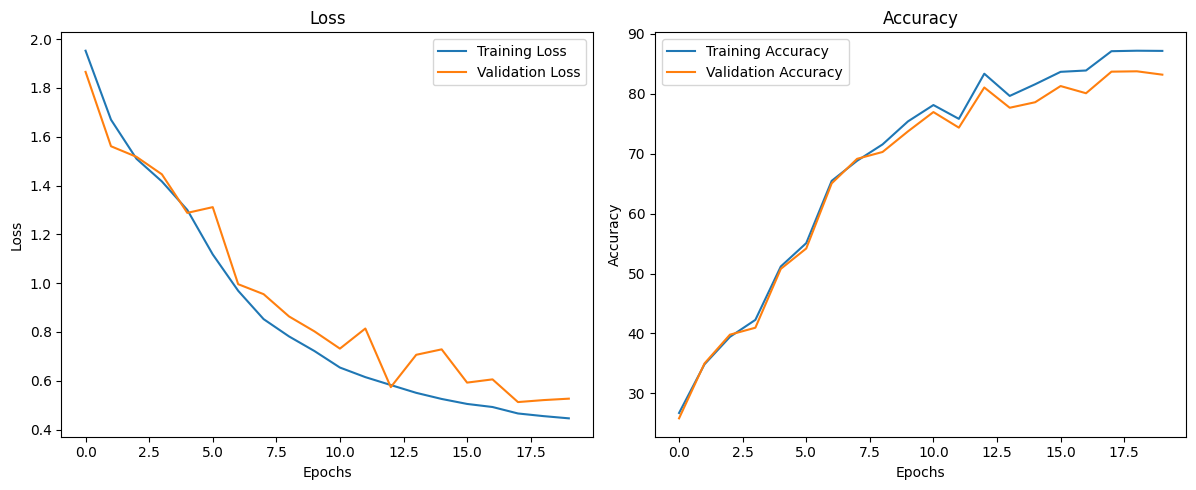

In [12]:
def plot_history(history):
    """
    Plots the training and validation loss, accuracy, and learning rate
    from a PyTorch history dictionary.

    Args:
        history (dict): Dictionary containing training metrics.
                        Expected keys: 'train_loss', 'val_loss', 'train_acc', 'val_acc', 'lrs'.
    """
    epochs = range(len(history['train_loss']))

    plt.figure(figsize=(18, 5))

    # Plot 1: Loss
    plt.subplot(1, 3, 1)
    plt.plot(epochs, history['train_loss'], label='Training Loss')
    plt.plot(epochs, history['val_loss'], label='Validation Loss')
    plt.title('Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    # plt.grid(True)

    # Plot 2: Accuracy
    plt.subplot(1, 3, 2)
    plt.plot(epochs, history['train_acc'], label='Training Accuracy')
    plt.plot(epochs, history['val_acc'], label='Validation Accuracy')
    plt.title('Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    # plt.grid(True)

    plt.tight_layout()
    plt.show() 
    # plt.savefig() 

plot_history(history)